# 01. LLM + V-JEPA + π0 아키텍처 분석

**모듈**: M4 - Architecture Analysis
**날짜**: 2026-03-11

세 가지 핵심 아키텍처를 코드와 다이어그램으로 비교합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False
print('라이브러리 로드 완료!')

라이브러리 로드 완료!


## 1. World Model 발전 타임라인

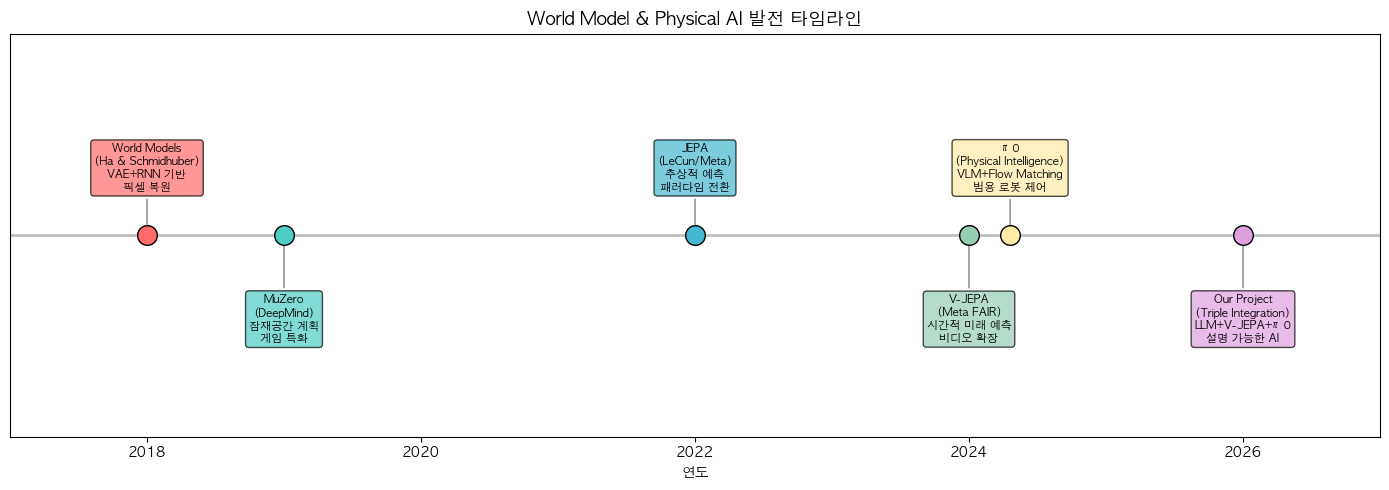

In [2]:
# World Model 발전 타임라인
fig, ax = plt.subplots(figsize=(14, 5))

models = [
    (2018, 'World Models\n(Ha & Schmidhuber)', 'VAE+RNN 기반\n픽셀 복원', '#FF6B6B'),
    (2019, 'MuZero\n(DeepMind)', '잠재공간 계획\n게임 특화', '#4ECDC4'),
    (2022, 'JEPA\n(LeCun/Meta)', '추상적 예측\n패러다임 전환', '#45B7D1'),
    (2024.0, 'V-JEPA\n(Meta FAIR)', '시간적 미래 예측\n비디오 확장', '#96CEB4'),
    (2024.3, 'π0\n(Physical Intelligence)', 'VLM+Flow Matching\n범용 로봇 제어', '#FFEAA7'),
    (2026, 'Our Project\n(Triple Integration)', 'LLM+V-JEPA+π0\n설명 가능한 AI', '#DDA0DD'),
]

for i, (year, name, desc, color) in enumerate(models):
    ax.scatter(year, 0, s=200, c=color, zorder=5, edgecolors='black')
    y_offset = 0.4 if i % 2 == 0 else -0.5
    ax.annotate(f'{name}\n{desc}',
                xy=(year, 0), xytext=(year, y_offset),
                ha='center', va='center', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='gray'))

ax.axhline(y=0, color='gray', linewidth=2, alpha=0.5)
ax.set_xlim(2017, 2027)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel('연도')
ax.set_title('World Model & Physical AI 발전 타임라인', fontweight='bold', fontsize=13)
ax.set_yticks([])
plt.tight_layout()
plt.show()

## 2. V-JEPA vs MuZero vs JEPA 비교

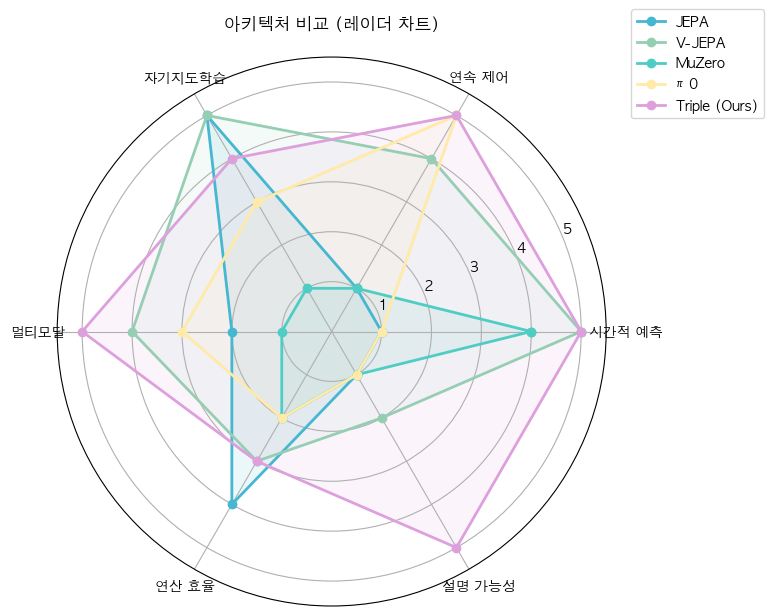

In [3]:
# 레이더 차트로 비교
categories = ['시간적 예측', '연속 제어', '자기지도학습', '멀티모달', '연산 효율', '설명 가능성']
N = len(categories)

# 각 모델의 점수 (0-5)
scores = {
    'JEPA':   [1, 1, 5, 2, 4, 1],
    'V-JEPA': [5, 4, 5, 4, 3, 2],
    'MuZero': [4, 1, 1, 1, 2, 1],
    'π0':     [1, 5, 3, 3, 2, 1],
    'Triple (Ours)': [5, 5, 4, 5, 3, 5],
}

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # 닫기

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#45B7D1', '#96CEB4', '#4ECDC4', '#FFEAA7', '#DDA0DD']

for (name, vals), color in zip(scores.items(), colors):
    vals_closed = vals + vals[:1]
    ax.plot(angles, vals_closed, 'o-', linewidth=2, label=name, color=color)
    ax.fill(angles, vals_closed, alpha=0.1, color=color)

ax.set_thetagrids([a * 180/np.pi for a in angles[:-1]], categories)
ax.set_ylim(0, 5.5)
ax.set_title('아키텍처 비교 (레이더 차트)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 3. Triple Integration 파이프라인

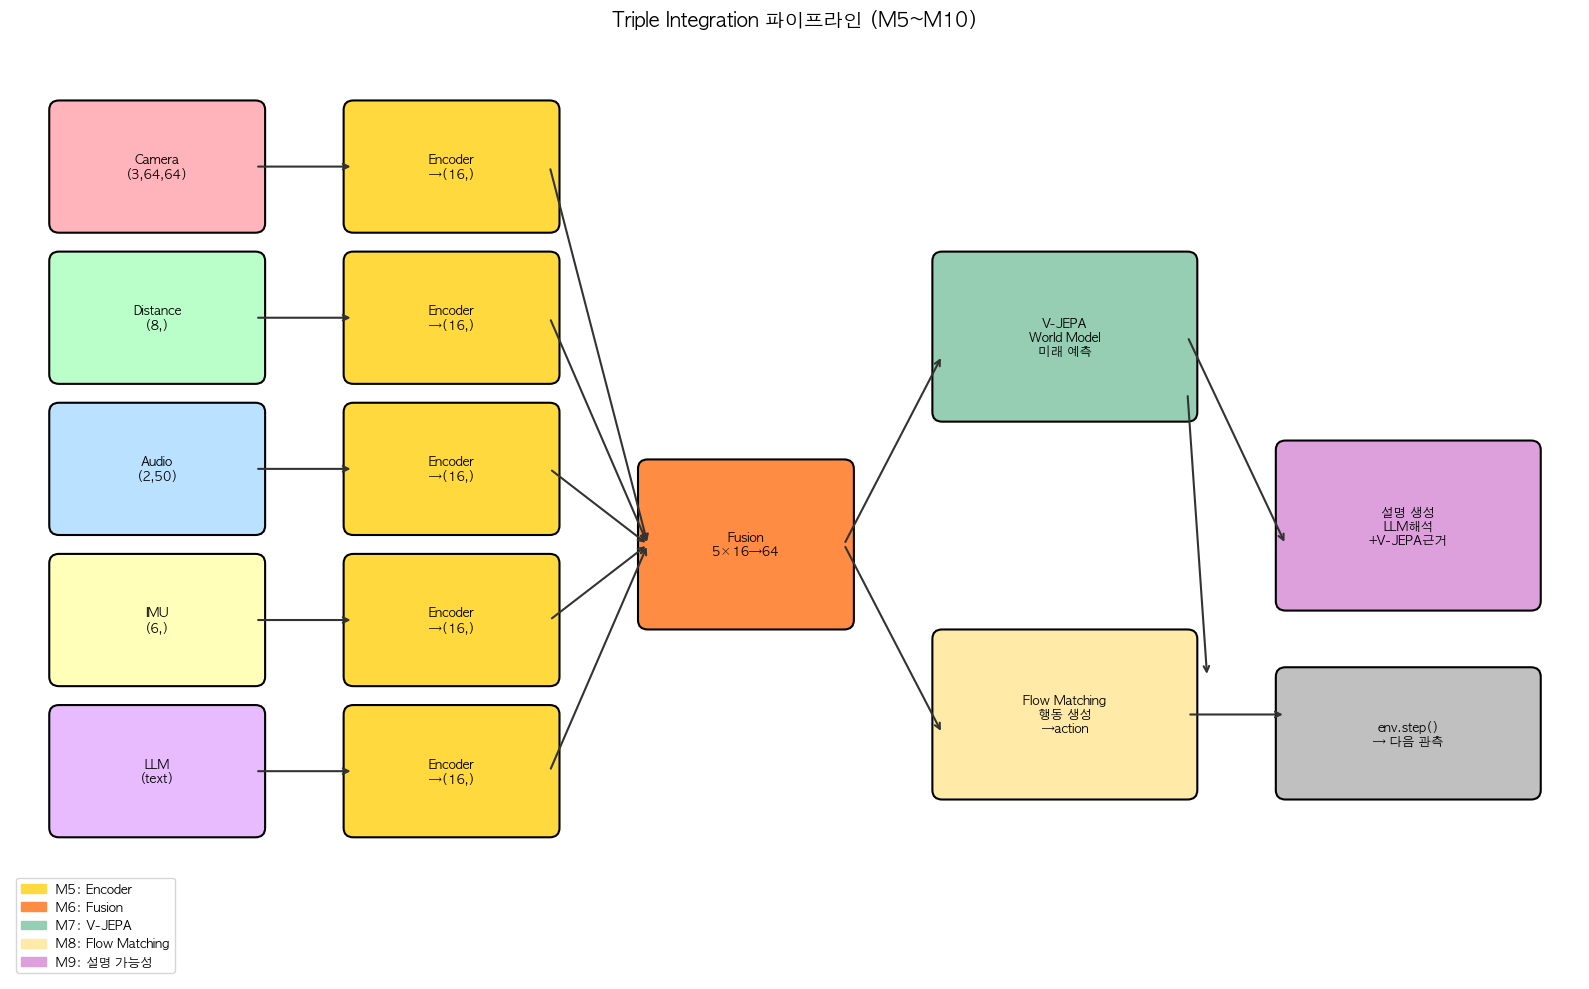

In [4]:
# Triple Integration 파이프라인 다이어그램
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')

def draw_box(ax, x, y, w, h, text, color, fontsize=9):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                                     facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=fontsize, fontweight='bold')

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

# 센서 (왼쪽)
sensors = ['Camera\n(3,64,64)', 'Distance\n(8,)', 'Audio\n(2,50)', 'IMU\n(6,)', 'LLM\n(text)']
sensor_colors = ['#FFB3BA', '#BAFFC9', '#BAE1FF', '#FFFFBA', '#E8BAFF']
for i, (s, c) in enumerate(zip(sensors, sensor_colors)):
    y = 8 - i * 1.6
    draw_box(ax, 0.5, y, 2, 1.2, s, c)
    draw_arrow(ax, 2.5, y+0.6, 3.5, y+0.6)

# Encoder (M5)
for i in range(5):
    y = 8 - i * 1.6
    draw_box(ax, 3.5, y, 2, 1.2, f'Encoder\n→(16,)', '#FFD93D')
    draw_arrow(ax, 5.5, y+0.6, 6.5, 4.6)

# Fusion (M6)
draw_box(ax, 6.5, 3.8, 2, 1.6, 'Fusion\n5×16→64', '#FF8C42')
draw_arrow(ax, 8.5, 4.6, 9.5, 6.6)  # → V-JEPA
draw_arrow(ax, 8.5, 4.6, 9.5, 2.6)  # → Flow Matching

# V-JEPA (M7)
draw_box(ax, 9.5, 6, 2.5, 1.6, 'V-JEPA\nWorld Model\n미래 예측', '#96CEB4')
draw_arrow(ax, 12, 6.8, 13, 4.6)  # → 설명
draw_arrow(ax, 12, 6.2, 12.2, 3.2)  # → FM

# Flow Matching (M8)
draw_box(ax, 9.5, 2, 2.5, 1.6, 'Flow Matching\n행동 생성\n→action', '#FFEAA7')
draw_arrow(ax, 12, 2.8, 13, 2.8)  # → 환경

# 설명 (M9)
draw_box(ax, 13, 4, 2.5, 1.6, '설명 생성\nLLM해석\n+V-JEPA근거', '#DDA0DD')

# 행동 출력
draw_box(ax, 13, 2, 2.5, 1.2, 'env.step()\n→ 다음 관측', '#C0C0C0')

# 제목
ax.set_title('Triple Integration 파이프라인 (M5~M10)', fontsize=14, fontweight='bold')

# 범례
legend_items = [
    ('M5: Encoder', '#FFD93D'),
    ('M6: Fusion', '#FF8C42'),
    ('M7: V-JEPA', '#96CEB4'),
    ('M8: Flow Matching', '#FFEAA7'),
    ('M9: 설명 가능성', '#DDA0DD'),
]
patches = [mpatches.Patch(color=c, label=l) for l, c in legend_items]
ax.legend(handles=patches, loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Flow Matching 직관적 이해

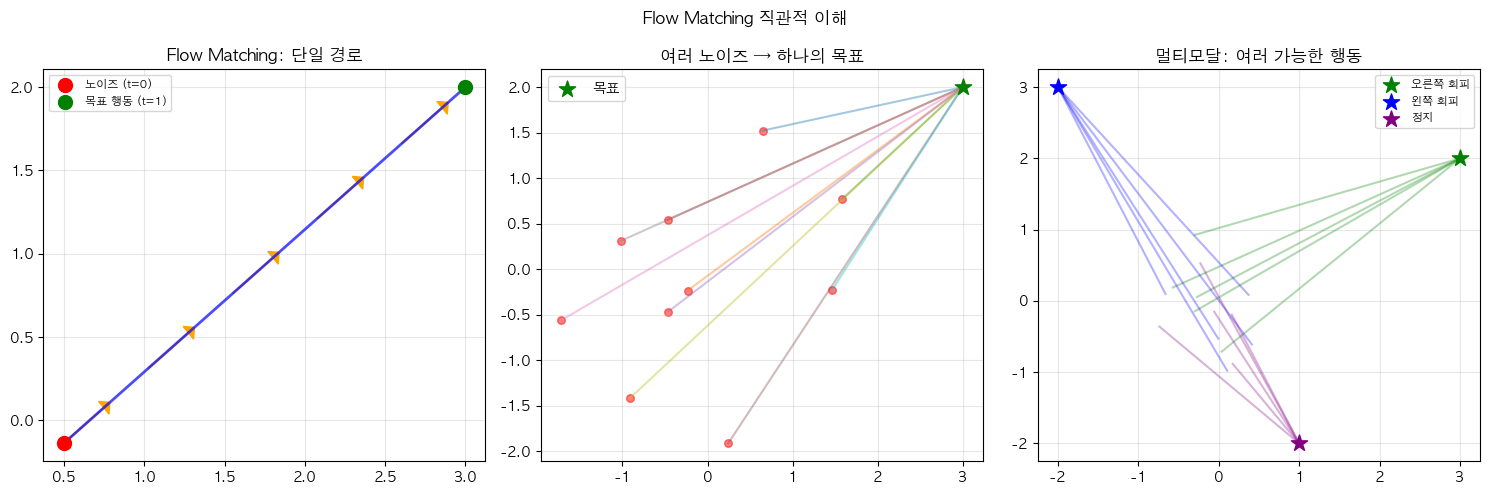


핵심 포인트:
  1. 노이즈에서 목표로 직선 경로를 따라감
  2. 어디서 시작해도 같은 목표에 도달
  3. 같은 상황에서도 여러 행동 가능 (멀티모달)


In [5]:
# Flow Matching 시각화: 노이즈 → 목표로의 직선 경로
np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. 단일 경로
ax = axes[0]
x0 = np.random.randn(2)  # 노이즈
x1 = np.array([3.0, 2.0])  # 목표 행동
ts = np.linspace(0, 1, 20)
path = np.array([(1-t)*x0 + t*x1 for t in ts])

ax.plot(path[:, 0], path[:, 1], 'b-', linewidth=2, alpha=0.7)
ax.scatter(*x0, c='red', s=100, zorder=5, label='노이즈 (t=0)')
ax.scatter(*x1, c='green', s=100, zorder=5, label='목표 행동 (t=1)')
# 속도 벡터
for i in range(0, len(ts), 4):
    v = x1 - x0
    ax.arrow(path[i, 0], path[i, 1], v[0]*0.1, v[1]*0.1,
             head_width=0.1, head_length=0.05, fc='orange', ec='orange')
ax.set_title('Flow Matching: 단일 경로')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2. 여러 시작점 → 같은 목표
ax = axes[1]
for _ in range(10):
    x0 = np.random.randn(2)
    path = np.array([(1-t)*x0 + t*x1 for t in ts])
    ax.plot(path[:, 0], path[:, 1], '-', alpha=0.4, linewidth=1.5)
    ax.scatter(*x0, c='red', s=30, alpha=0.5)
ax.scatter(*x1, c='green', s=150, zorder=5, marker='*', label='목표')
ax.set_title('여러 노이즈 → 하나의 목표')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. 멀티모달: 여러 가능한 목표
ax = axes[2]
goals = [np.array([3.0, 2.0]), np.array([-2.0, 3.0]), np.array([1.0, -2.0])]
goal_names = ['오른쪽 회피', '왼쪽 회피', '정지']
colors = ['green', 'blue', 'purple']
for goal, name, color in zip(goals, goal_names, colors):
    for _ in range(5):
        x0 = np.random.randn(2) * 0.5
        path = np.array([(1-t)*x0 + t*goal for t in ts])
        ax.plot(path[:, 0], path[:, 1], '-', alpha=0.3, color=color, linewidth=1.5)
    ax.scatter(*goal, c=color, s=150, zorder=5, marker='*', label=name)
ax.set_title('멀티모달: 여러 가능한 행동')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Flow Matching 직관적 이해', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n핵심 포인트:')
print('  1. 노이즈에서 목표로 직선 경로를 따라감')
print('  2. 어디서 시작해도 같은 목표에 도달')
print('  3. 같은 상황에서도 여러 행동 가능 (멀티모달)')

## 5. V-JEPA 마스킹 시각화

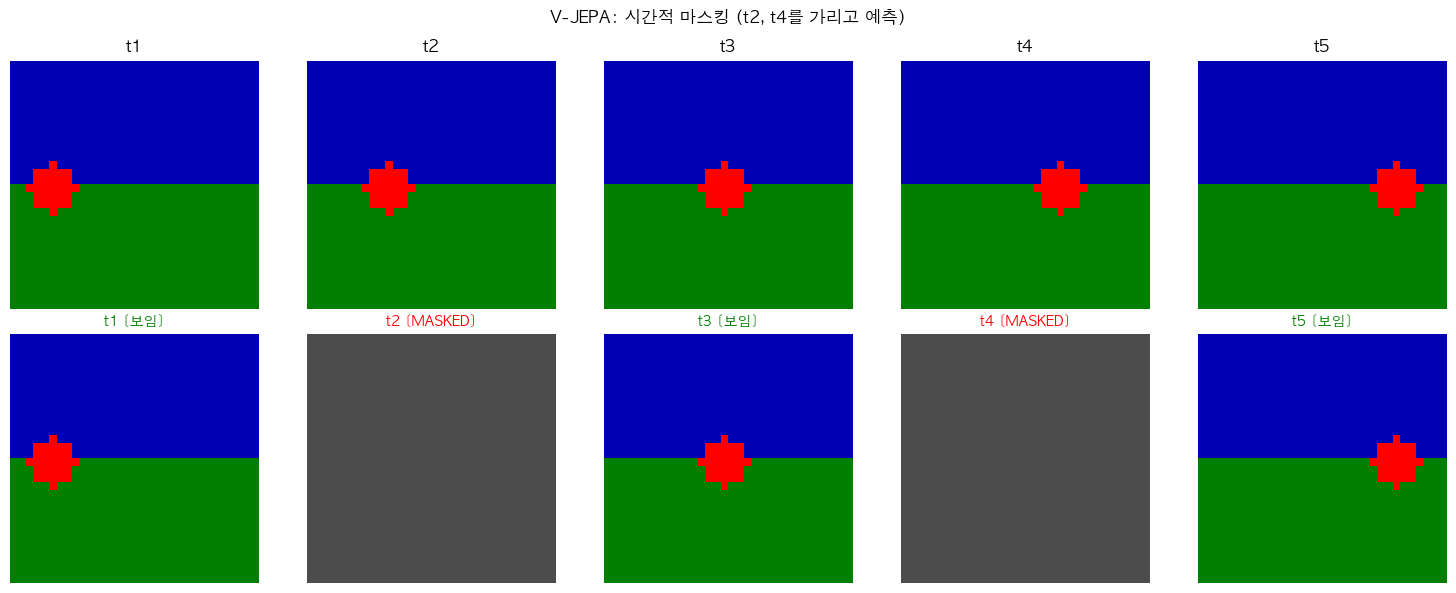

V-JEPA 학습 과정:
  1. 원본 비디오에서 일부 프레임을 마스킹 (75-90%)
  2. Context Encoder: 보이는 프레임 → 잠재 표현
  3. Predictor: 보이는 표현 → 가려진 프레임의 표현 예측
  4. Target Encoder (EMA): 가려진 프레임의 "정답" 표현 생성
  5. Loss = L2(predicted, target) — 잠재공간에서의 거리


In [6]:
# V-JEPA 시공간 마스킹 시각화
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# 원본 비디오 프레임 (단순화)
np.random.seed(42)
for i in range(5):
    # 간단한 이미지: 원이 이동
    img = np.zeros((32, 32, 3))
    img[:16, :, 2] = 0.7  # 하늘
    img[16:, :, 1] = 0.5  # 바닥
    cx, cy = 5 + i * 5, 16
    for dx in range(-3, 4):
        for dy in range(-3, 4):
            if dx**2 + dy**2 <= 9 and 0 <= cx+dx < 32 and 0 <= cy+dy < 32:
                img[cy+dy, cx+dx] = [1, 0, 0]  # 빨간 원
    
    axes[0, i].imshow(img)
    axes[0, i].set_title(f't{i+1}', fontsize=12)
    axes[0, i].axis('off')

# 마스킹된 버전
mask_frames = [1, 3]  # t2, t4를 마스킹
for i in range(5):
    if i in mask_frames:
        # 마스킹된 프레임
        masked = np.ones((32, 32, 3)) * 0.3  # 회색
        axes[1, i].imshow(masked)
        axes[1, i].set_title(f't{i+1} [MASKED]', fontsize=10, color='red')
    else:
        img = np.zeros((32, 32, 3))
        img[:16, :, 2] = 0.7
        img[16:, :, 1] = 0.5
        cx, cy = 5 + i * 5, 16
        for dx in range(-3, 4):
            for dy in range(-3, 4):
                if dx**2 + dy**2 <= 9 and 0 <= cx+dx < 32 and 0 <= cy+dy < 32:
                    img[cy+dy, cx+dx] = [1, 0, 0]
        axes[1, i].imshow(img)
        axes[1, i].set_title(f't{i+1} [보임]', fontsize=10, color='green')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('원본', fontsize=12, rotation=0, labelpad=40)
axes[1, 0].set_ylabel('마스킹', fontsize=12, rotation=0, labelpad=40)

plt.suptitle('V-JEPA: 시간적 마스킹 (t2, t4를 가리고 예측)', fontweight='bold')
plt.tight_layout()
plt.show()

print('V-JEPA 학습 과정:')
print('  1. 원본 비디오에서 일부 프레임을 마스킹 (75-90%)')
print('  2. Context Encoder: 보이는 프레임 → 잠재 표현')
print('  3. Predictor: 보이는 표현 → 가려진 프레임의 표현 예측')
print('  4. Target Encoder (EMA): 가려진 프레임의 "정답" 표현 생성')
print('  5. Loss = L2(predicted, target) — 잠재공간에서의 거리')

## 6. 차원(Dimension) 설계 요약

In [7]:
# 각 컴포넌트의 입출력 차원 정리
components = [
    ('Camera', '(3, 64, 64)', '12,288', 'CNN Encoder', '(16,)', '16'),
    ('Distance', '(8,)', '8', 'MLP Encoder', '(16,)', '16'),
    ('Audio', '(2, 50)', '100', 'Conv1D Encoder', '(16,)', '16'),
    ('IMU', '(6,)', '6', 'MLP Encoder', '(16,)', '16'),
    ('LLM text', '(seq_len,)', '~50', 'Lang Encoder', '(16,)', '16'),
    ('─'*8, '─'*10, '─'*6, '─'*12, '─'*8, '─'*4),
    ('5 Encoders', '5 × (16,)', '80', 'Fusion (M6)', '(64,)', '64'),
    ('Fused seq', 'T × (64,)', 'T×64', 'V-JEPA (M7)', 'N × (64,)', 'N×64'),
    ('State+Pred', '(128,)', '128', 'Flow Match (M8)', '(action_dim,)', '8 or 2'),
]

print('=== Triple Integration 차원 설계 ===')
print(f'{"컴포넌트":>12} | {"입력 shape":>12} | {"입력 dim":>8} | {"모듈":>14} | {"출력 shape":>10} | {"출력 dim":>8}')
print('-' * 85)
for name, in_shape, in_dim, module, out_shape, out_dim in components:
    print(f'{name:>12} | {in_shape:>12} | {in_dim:>8} | {module:>14} | {out_shape:>10} | {out_dim:>8}')

print(f'\n총 파라미터 추정: ~500K - 1M (교육용 규모)')
print(f'π0 원본: ~3B (3000배 차이 → 우리는 핵심 구조만 차용)')

=== Triple Integration 차원 설계 ===
        컴포넌트 |     입력 shape |   입력 dim |             모듈 |   출력 shape |   출력 dim
-------------------------------------------------------------------------------------
      Camera |  (3, 64, 64) |   12,288 |    CNN Encoder |      (16,) |       16
    Distance |         (8,) |        8 |    MLP Encoder |      (16,) |       16
       Audio |      (2, 50) |      100 | Conv1D Encoder |      (16,) |       16
         IMU |         (6,) |        6 |    MLP Encoder |      (16,) |       16
    LLM text |   (seq_len,) |      ~50 |   Lang Encoder |      (16,) |       16
    ──────── |   ────────── |   ────── |   ──────────── |   ──────── |     ────
  5 Encoders |    5 × (16,) |       80 |    Fusion (M6) |      (64,) |       64
   Fused seq |    T × (64,) |     T×64 |    V-JEPA (M7) |  N × (64,) |     N×64
  State+Pred |       (128,) |      128 | Flow Match (M8) | (action_dim,) |   8 or 2

총 파라미터 추정: ~500K - 1M (교육용 규모)
π0 원본: ~3B (3000배 차이 → 우리는 핵심 구조만 차용)


## 7. 정리

In [8]:
print('=== M4 실습 1: 아키텍처 분석 정리 ===')
print()
print('1. World Model 발전: 픽셀복원(2018) → 잠재예측(2019) → 추상예측(2022) → 시간예측(2024)')
print('2. V-JEPA: 비디오 마스킹 → 잠재공간에서 미래 표현 예측 → 우리 World Model')
print('3. π0: VLM + Flow Matching → 부드러운 범용 로봇 제어 → 행동 생성 차용')
print('4. LLM as Sensor: 양방향 (상황해석 + 명령수신) → 의미 차원 추가')
print('5. Triple Integration = LLM(왜?) + V-JEPA(앞으로?) + FM(어떻게?) = 설명 가능한 Physical AI')
print()
print('다음: 실습 2 - openpi/V-JEPA 코드 구조 탐색')

=== M4 실습 1: 아키텍처 분석 정리 ===

1. World Model 발전: 픽셀복원(2018) → 잠재예측(2019) → 추상예측(2022) → 시간예측(2024)
2. V-JEPA: 비디오 마스킹 → 잠재공간에서 미래 표현 예측 → 우리 World Model
3. π0: VLM + Flow Matching → 부드러운 범용 로봇 제어 → 행동 생성 차용
4. LLM as Sensor: 양방향 (상황해석 + 명령수신) → 의미 차원 추가
5. Triple Integration = LLM(왜?) + V-JEPA(앞으로?) + FM(어떻게?) = 설명 가능한 Physical AI

다음: 실습 2 - openpi/V-JEPA 코드 구조 탐색
